<a href="https://colab.research.google.com/github/shaevitz/MOL518-Intro-to-Data-Analysis/blob/main/Lecture_14/MOL518_Lecture14_with_answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# In colab run this cell first to setup the file structure!
%cd /content
!rm -rf MOL518-Intro-to-Data-Analysis

!git clone https://github.com/shaevitz/MOL518-Intro-to-Data-Analysis.git
%cd MOL518-Intro-to-Data-Analysis/Lecture_14

# Lecture 14: Binary Classification

This notebook introduces binary classification through examples inspired by molecular biology. Many biological questions boil down to deciding between two states: whether an enzyme is active or inactive, whether a cell is stem-like or differentiated, or whether a signal is significant or not. These decisions often rely on quantitative measurements that are noisy, complex, and influenced by multiple factors. By working through synthetic datasets, you will practice building models that make these decisions in a principled way.

Binary classification is a natural fit for many biological workflows because it provides a structured way to convert continuous or multivariate measurements into interpretable decisions. Throughout this notebook, we will connect statistical modeling to the kinds of reasoning biologists use when interpreting experiments. The goal is not only to learn the mechanics of classification but also to understand how these tools support real scientific inference.

## Example 1: GFP expression classification

When we transfect mammalian cells, we often use a plasmid expressing a fluorescent marker protein, as tranfection efficiency is quite variable both across experimental replicates and between cell lines (and for different types of plasmids). Here, we will be considering a very simple case where there is a single transfected plasmid.

### Data Generation

In this example, we are generating a synthetic dataset representing GFP expresssion under different conditions, one where GFP is expressed (`GFP_on`) and one where GFP is not expressed (`GFP_off`). The combined dataset is just called `GFP`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

RNG = np.random.default_rng(42)

In [ ]:
# Generate synthetic GFP expression dataset dataset
n = 500
GFP_off = RNG.normal(100.0, 35.0, size=n)
GFP_on = RNG.normal(225.0, 50.0, size=int(n/4))

GFP = np.concatenate([GFP_off, GFP_on])



## Exercise 1: Plot the data

Plost histograms of `GFP_off`, `GFP_on`, as well as the combined distribution `GFP`. I would recomment showing `GFP` on separate axes from `GFP_off` and `GFP_on`.

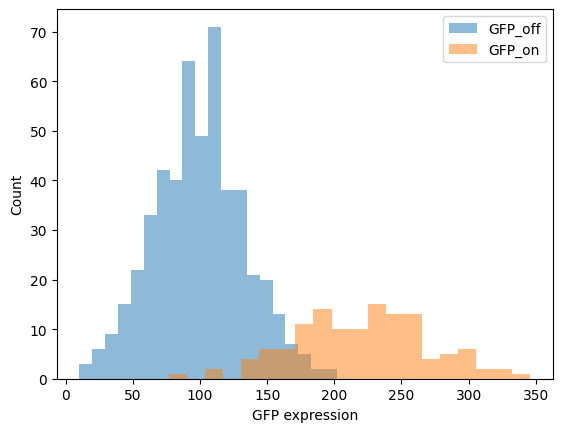

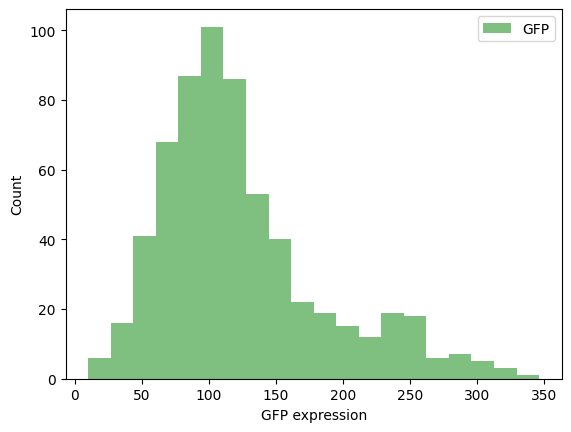

TtestResult(statistic=np.float64(-25.629520418354733), pvalue=np.float64(3.0845395973129555e-57), df=np.float64(152.99753864605577))

In [ ]:
# your code for Exercise 1 goes here

plt.hist(GFP_off, bins=20, alpha=0.5, label='GFP_off')
plt.hist(GFP_on, bins=20, alpha=0.5, label='GFP_on')
plt.xlabel('GFP expression')
plt.ylabel('Count')
plt.legend()
plt.show()

plt.hist(GFP, bins=20, alpha=0.5, label='GFP', facecolor='g')
plt.xlabel('GFP expression')
plt.ylabel('Count')
plt.legend()
plt.show()

scipy.stats.ttest_ind(GFP_off, GFP_on, equal_var=False)

### Questions related to Exercise 1:

1. How well-separated are `GFP_off` and `GFP_on`?

**The distributions are fairly well-separated, but not perfectly**

2. Why are the bins different in width for the two distributions?

**In part because there is more data for GFP_off, but also because the variance of GFP_on is a bit higher than GFP_off**

3. Are the means of `GFP_off` and `GFP_on` significantly different from one another? Please perform the relevant statistical test.

**Yes, they are significantly different. The p value is very low ($< 10^{-50}$) based on Welch's t test.**

## Exercise 2: ROC Curve Calculation

The ROC curve provides a threshold‑independent view of classifier performance by plotting the true positive rate against the false positive rate. This is especially useful in biology, where the cost of false positives and false negatives can vary depending on the experimental context. The area under the curve (AUC) summarizes overall performance.

The ROC curve is defined by evaluating the classifier at different probability thresholds. For each threshold \(t\), we compute:

$\text{TPR}(t) = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$

$\text{FPR}(t) = \frac{\text{False Positives}}{\text{False Positives} + \text{True Negatives}}$

These expressions quantify how sensitive and how permissive the classifier is at each threshold. Plotting them together reveals how well the model separates the two classes.

Write some code to calculate a ROC curve for the GFP dataset.

### Exercise 3: Plotting the ROC Curve

Now, plot the ROC curve for this dataset and compute the area under the curve (AUC).

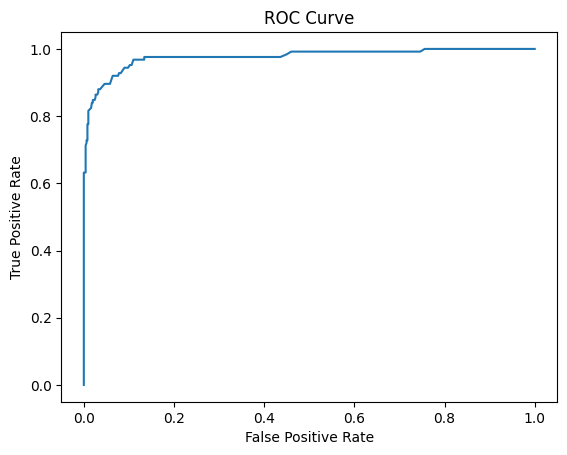

np.float64(0.9764560000000001)

In [ ]:
# your code for Exercise 3 goes here
import sklearn

tprate = []
fprate = []

for t in np.linspace(0, 400, 401):
    tpr = np.sum(GFP_on > t) / (np.sum(GFP_on > t) + np.sum(GFP_on < t))
    fpr = np.sum(GFP_off > t) / (np.sum(GFP_off > t) + np.sum(GFP_off < t))
    tprate.append(tpr)
    fprate.append(fpr)

plt.plot(fprate, tprate, '-')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

sklearn.metrics.auc(fprate, tprate)

### Questions related to Exercise 3:

1. How well is the classifier working?

** The classifier is working fairly well, based on the ROC curve.**

2. What is the AUC?

**It is approximately 0.97 (the exact value depends on how many thresholds you choose for your ROC curve).**

## Exercise 4: Handling Class Imbalance

In this exercise, you will apply oversampling to make a new dataset that has balance between the classes, and compare model performance before and after balancing. This illustrates how resampling strategies can improve classifier sensitivity to rare events.

### Class Imbalance and Its Consequences

Many biological datasets are imbalanced—for example, only a small fraction of cells may express a rare marker, or only a few compounds in a screen may be active. Class imbalance can distort model performance because accuracy becomes dominated by the majority class. Understanding how imbalance affects learning is essential for building reliable models.

One common strategy is oversampling the minority class, which increases its representation in the training data. This helps the model learn patterns associated with the minority class more effectively. In this section, we explore how oversampling affects logistic regression performance.

Using bootstrapping, resample the minor class so that it has the same sample size as the major class. Then, recalculate the and plot the ROC curve. Please plot both ROC curves (before and after resampling) so that you can compare them.

Also compute the AUC and print that.

In [ ]:
# your code for Exercise 4 goes here


### Questions associated with Exercise 4

1. What is one problem associated with class imbalance?

**[your answer goes here]**

2. Come up with an example where resampling is not sufficient for handling class imbalance.

**[your answer goes here]**

## Wrap-Up and Reflection

You have now walked through a complete mini‑pipeline for binary classification in a molecular biology context. Starting from a synthetic enzyme activity dataset, you explored features, engineered new ones, and fit a logistic regression model from scratch. You then evaluated the model using accuracy, confusion matrices, and ROC/AUC, and saw how class imbalance can distort performance.

The key idea is that statistical models provide a structured way to turn noisy, multivariate measurements into interpretable decisions. In real research, these tools help you decide which compounds to follow up on, which cells to sort, or which conditions to test next. As you move on, keep connecting the math back to the biological questions you care about.